### Analisis Deskriptif & Sentimen

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('dataset/data_ready_for_modeling.csv')
df.head()

positive = pd.read_csv(
    "dataset/lexicon/positive.tsv",
    sep="\t",
    header=None,
    encoding="utf-8",
    skiprows=1,
    usecols=[0, 1]
)

negative = pd.read_csv(
    "dataset/lexicon/negative.tsv",
    sep="\t",
    header=None,
    encoding="utf-8",
    skiprows=1,
    usecols=[0, 1]
)

pos_dict = {str(k).strip(): float(v) for k, v in zip(positive[0], positive[1])}
neg_dict = {str(k).strip(): float(v) for k, v in zip(negative[0], negative[1])}

,reviewId,content,score,at,source,cleaned_content,normalized_text,no_stop_text,tokenized_text,stemmed_tokens,stemmed_text,label,len_words
0,d84a4955-4bfb-448b-a260-b36935a58c9b,kalo ada pembatalan hub langsung WA dong,1,2026-01-13 12:12:06,tiketcom,kalo ada pembatalan hub langsung wa dong,kalau ada pembatalan hub langsung wa dong,kalau pembatalan hub langsung wa dong,"['kalau', 'pembatalan', 'hub', 'langsung', 'wa...","['kalau', 'batal', 'hub', 'langsung', 'wa', 'd...",kalau batal hub langsung wa dong,negatif,6
1,0b67f755-1fb1-4300-a769-68e45a0a48cc,ganguan terus susah cari jadwal disni,2,2026-01-13 11:18:17,tiketcom,ganguan terus susah cari jadwal disni,ganguan terus susah cari jadwal disni,ganguan terus susah cari jadwal disni,"['ganguan', 'terus', 'susah', 'cari', 'jadwal'...","['ganguan', 'terus', 'susah', 'cari', 'jadwal'...",ganguan terus susah cari jadwal disni,negatif,6
2,fcef9cb8-5c08-41cf-a8b5-2a2eb1edfba8,banyakin promonya ya,5,2026-01-13 00:01:23,tiketcom,banyakin promonya ya,dibanyaki promonya ya,dibanyaki promonya,"['dibanyaki', 'promonya']","['banyak', 'promonya']",banyak promonya,positif,2
3,d039ee95-c3f2-4e76-ae03-9214f7672cd8,very bad service!!!!!!,1,2026-01-12 21:29:45,tiketcom,very bad service,very bad service,very bad service,"['very', 'bad', 'service']","['very', 'bad', 'service']",very bad service,negatif,3
4,0d830287-f7df-454c-9598-4d6a6071b32a,mantap,5,2026-01-12 13:02:48,tiketcom,mantap,mantap,mantap,['mantap'],['mantap'],mantap,positif,1


In [16]:
df["source"].value_counts() 

source
tiketcom     3567
traveloka    3566
Name: count, dtype: int64

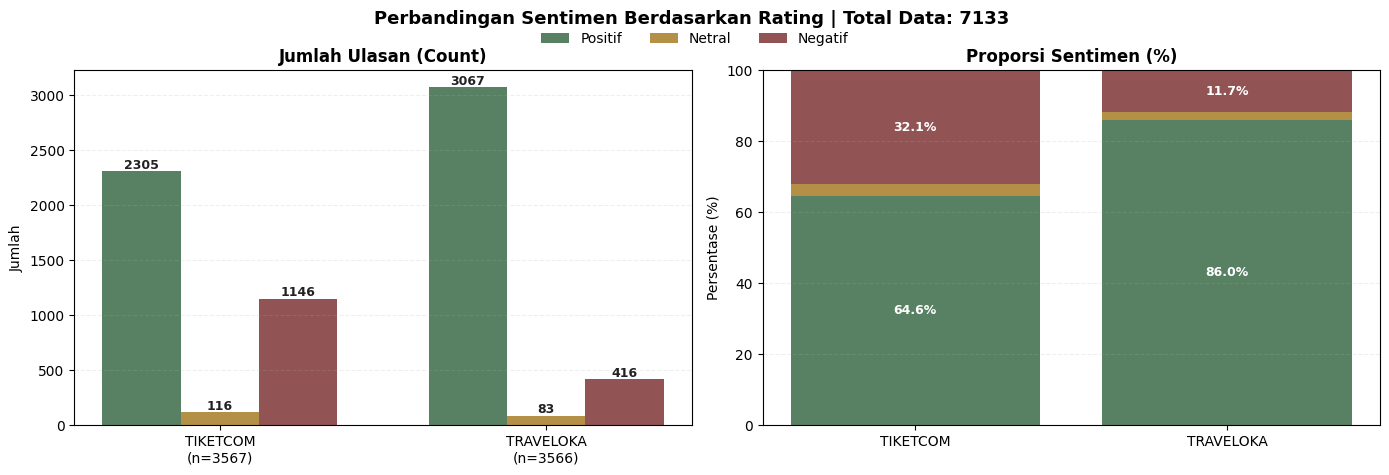

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Labeling 3 kelas (rating-based)
def label_rating(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df["label"] = df["score"].apply(label_rating)

def plot_sentiment_compare(df, source_col="source", label_col="label", date_col="at"):
    order = ["positif", "netral", "negatif"]

    # Pastikan kolom tanggal valid
    dfx = df.copy()
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")

    total_all = len(dfx)
    start_date = dfx[date_col].min()
    end_date = dfx[date_col].max()
    date_info = ""
    if pd.notna(start_date) and pd.notna(end_date):
        date_info = f"{start_date:%Y-%m-%d} s/d {end_date:%Y-%m-%d}"
    else:
        date_info = "Tanggal tidak tersedia/invalid"

    # Count per source x label
    counts = (
        dfx.groupby([source_col, label_col])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=order, fill_value=0)
    )

    # Persentase per source
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    sources = counts.index.tolist()
    totals = counts.sum(axis=1).astype(int).tolist()

    x = np.arange(len(sources))
    width = 0.24

    # Warna muted (lebih redup)
    colors = {
        "positif": "#4E7A5A",  # muted green
        "netral":  "#B08A3D",  # muted amber
        "negatif": "#8B4A4A",  # muted red
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    fig.suptitle(
        f"Perbandingan Sentimen Berdasarkan Rating | Total Data: {total_all} ",
        fontsize=13,
        fontweight="bold"
    )

    # ========= (A) COUNT =========
    ax = axes[0]
    for i, lab in enumerate(order):
        vals = counts[lab].values
        bars = ax.bar(
            x + (i - 1) * width,
            vals,
            width=width,
            label=lab.capitalize(),
            color=colors[lab],
            alpha=0.95
        )

        # angka di atas bar
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width()/2,
                h,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="#222222"
            )

    ax.set_title("Jumlah Ulasan (Count)", fontweight="bold")
    ax.set_ylabel("Jumlah")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s.upper()}\n(n={t})" for s, t in zip(sources, totals)])
    ax.grid(axis="y", linestyle="--", alpha=0.20)

    # ========= (B) PERCENT (100% STACKED) =========
    ax = axes[1]
    bottom = np.zeros(len(sources))
    for lab in order:
        vals = pct[lab].values
        bars = ax.bar(
            x,
            vals,
            bottom=bottom,
            label=lab.capitalize(),
            color=colors[lab],
            alpha=0.95
        )

        # label persen (biar tidak ramai: hanya segmen >= 7%)
        for b, v in zip(bars, vals):
            if v >= 7:
                ax.text(
                    b.get_x() + b.get_width()/2,
                    b.get_y() + b.get_height()/2,
                    f"{v:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white",
                    fontweight="bold"
                )
        bottom += vals

    ax.set_title("Proporsi Sentimen (%)", fontweight="bold")
    ax.set_ylabel("Persentase (%)")
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in sources])
    ax.grid(axis="y", linestyle="--", alpha=0.20)

    # Legend rapi (sekali)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.96))

    plt.tight_layout()
    plt.show()

plot_sentiment_compare(df)


C:\Users\Kinan\AppData\Local\Temp\ipykernel_104076\3230790221.py:124: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.10])  # <-- batasi area layout di bawah header


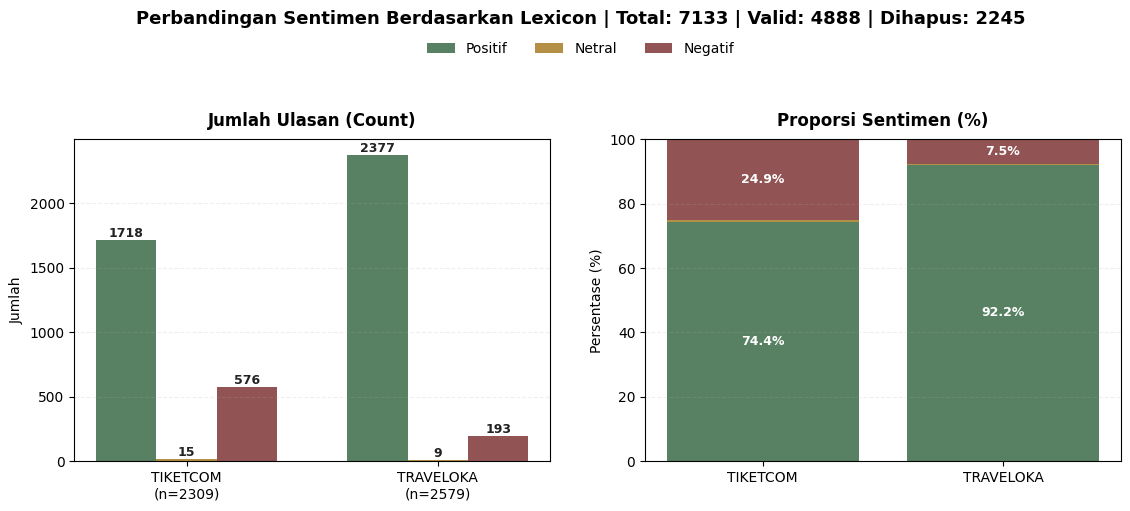

Total: 7133 | Valid (rating==lexicon): 4888 | Dihapus: 2245


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_valid_lexicon_like_rating(
    df,
    src_left="tiketcom",
    src_right="traveloka",
    source_col="source",
    date_col="at",
    rating_col="label_rating",
    lex_col="label_lexicon"
):
    order = ["positif", "netral", "negatif"]

    # warna muted
    colors = {
        "positif": "#4E7A5A",
        "netral":  "#B08A3D",
        "negatif": "#8B4A4A",
    }

    dfx = df.copy()
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")

    # VALIDASI: hanya data yang label rating == label lexicon
    df_valid = dfx[dfx[rating_col] == dfx[lex_col]].copy()

    total_all = len(dfx)
    total_valid = len(df_valid)
    total_drop = total_all - total_valid

    use_sources = [src_left, src_right]
    counts = (
        df_valid[df_valid[source_col].isin(use_sources)]
        .groupby([source_col, lex_col])
        .size()
        .unstack(fill_value=0)
        .reindex(index=use_sources, columns=order, fill_value=0)
    )

    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    totals = counts.sum(axis=1).astype(int).tolist()

    x = np.arange(len(use_sources))
    width = 0.24

    # ===== FIGURE =====
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

    # judul lebih “naik” dan ada jarak
    fig.suptitle(
        f"Perbandingan Sentimen Berdasarkan Lexicon | Total: {total_all} | Valid: {total_valid} | Dihapus: {total_drop}",
        fontsize=13,
        fontweight="bold",
        y=1.05  # <-- naikin judul
    )

    # ========= (A) COUNT =========
    ax = axes[0]
    for i, lab in enumerate(order):
        vals = counts[lab].values
        bars = ax.bar(
            x + (i - 1) * width,
            vals,
            width=width,
            label=lab.capitalize(),
            color=colors[lab],
            alpha=0.95
        )
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width()/2, h, f"{int(h)}",
                ha="center", va="bottom", fontsize=9, fontweight="bold", color="#222222"
            )

    ax.set_title("Jumlah Ulasan (Count)", fontweight="bold", pad=10)
    ax.set_ylabel("Jumlah")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s.upper()}\n(n={t})" for s, t in zip(use_sources, totals)])
    ax.grid(axis="y", linestyle="--", alpha=0.20)

    # ========= (B) PERCENT =========
    ax = axes[1]
    bottom = np.zeros(len(use_sources))
    for lab in order:
        vals = pct[lab].values
        bars = ax.bar(
            x, vals, bottom=bottom,
            label=lab.capitalize(),
            color=colors[lab],
            alpha=0.95
        )
        for b, v in zip(bars, vals):
            if v >= 7:
                ax.text(
                    b.get_x() + b.get_width()/2,
                    b.get_y() + b.get_height()/2,
                    f"{v:.1f}%",
                    ha="center", va="center", fontsize=9, color="white", fontweight="bold"
                )
        bottom += vals

    ax.set_title("Proporsi Sentimen (%)", fontweight="bold", pad=10)
    ax.set_ylabel("Persentase (%)")
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in use_sources])
    ax.grid(axis="y", linestyle="--", alpha=0.20)

    # Legend diturunkan sedikit agar tidak nabrak judul
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01)  # <-- turunin legend sedikit
    )

    # kasih ruang atas untuk judul + legend
    fig.subplots_adjust(top=0.78)         # <-- ruang header
    plt.tight_layout(rect=[0, 0, 1, 0.10])  # <-- batasi area layout di bawah header
    plt.show()

    print(f"Total: {total_all} | Valid (rating==lexicon): {total_valid} | Dihapus: {total_drop}")

# PAKAI:
plot_valid_lexicon_like_rating(df, "tiketcom", "traveloka")


In [32]:
def label_with_lexicon(text):
    # handle NaN / float
    if pd.isna(text):
        return "netral"

    text = str(text).strip()
    if text == "":
        return "netral"

    score = 0.0
    for w in text.split():
        if w in pos_dict:
            score += pos_dict[w]
        elif w in neg_dict:
            score += neg_dict[w]

    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"
    
df["label_lexicon"] = df["stemmed_text"].apply(label_with_lexicon)
print(df["label_lexicon"].value_counts())


label_lexicon
positif    4898
negatif    1134
netral     1101
Name: count, dtype: int64


In [35]:
def label_from_rating(score):
    if score >= 4: return "positif"
    if score == 3: return "netral"
    return "negatif"

df["label_rating"] = df["score"].apply(label_from_rating)

def hybrid_lexicon_sentiment(stemmed_text, rating_label):
    # jika teks kosong -> pakai rating
    if pd.isna(stemmed_text) or str(stemmed_text).strip() == "":
        return rating_label

    s = 0.0
    for w in str(stemmed_text).split():
        if w in pos_dict:
            s += pos_dict[w]
        elif w in neg_dict:
            s += neg_dict[w]

    # dominan -> pakai lexicon, seimbang -> pakai rating
    if s > 0:
        return "positif"
    elif s < 0:
        return "negatif"
    else:
        return rating_label

df["label_hybrid"] = df.apply(lambda r: hybrid_lexicon_sentiment(r["stemmed_text"], r["label_rating"]), axis=1)
print(df["label_hybrid"].value_counts())


label_hybrid
positif    5866
negatif    1243
netral       24
Name: count, dtype: int64


In [40]:
df[df["label_lexicon"]=="netral"]["score"].value_counts().sort_index()


score
1     96
2     13
3     24
4     76
5    892
Name: count, dtype: int64

Total: 7133 | Sesuai: 5965 | Dihapus: 1168


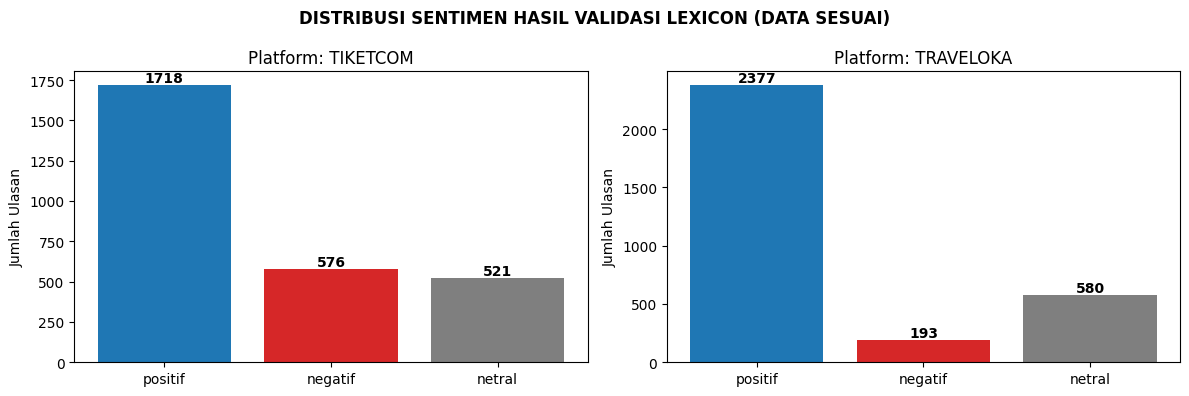

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_valid_lexicon_compare(df, src_left="tiketcom", src_right="traveloka",
                              rating_col="label_rating", lex_col="label_lexicon",
                              source_col="source", date_col="at"):
    order = ["positif", "netral", "negatif"]

    # warna muted (redup)
    colors = {
        "positif": "#4E7A5A",  # muted green
        "netral":  "#B08A3D",  # muted amber
        "negatif": "#8B4A4A",  # muted red
    }

    dfx = df.copy()
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")

    # filter data "sesuai" antara rating vs lexicon
    df_valid = dfx[dfx[rating_col] == dfx[lex_col]].copy()

    total_all = len(dfx)
    total_valid = len(df_valid)
    total_drop = total_all - total_valid

    start_date = dfx[date_col].min()
    end_date = dfx[date_col].max()
    date_info = f"{start_date:%Y-%m-%d} s/d {end_date:%Y-%m-%d}" if pd.notna(start_date) and pd.notna(end_date) else "Tanggal tidak tersedia"

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
    fig.suptitle(
        f"Distribusi Sentimen Hasil Validasi Lexicon (Data Sesuai) | Total: {total_all} | Valid: {total_valid} | Dihapus: {total_drop} | {date_info}",
        fontsize=11.5,
        fontweight="bold"
    )

    for ax, src in zip(axes, [src_left, src_right]):
        sub = df_valid[df_valid[source_col] == src]
        counts = sub[lex_col].value_counts().reindex(order).fillna(0).astype(int)
        n_src = int(counts.sum())

        bars = ax.bar(
            counts.index,
            counts.values,
            color=[colors[c] for c in counts.index],
            alpha=0.95
        )

        ax.set_title(f"{src.upper()} (n={n_src})", fontweight="bold")
        ax.set_xlabel("Label Sentimen (Lexicon)")
        ax.set_ylabel("Jumlah Ulasan")
        ax.grid(axis="y", linestyle="--", alpha=0.20)

        # angka di atas bar
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width()/2,
                h,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                color="#222222"
            )

    plt.tight_layout()
    plt.show()

    # opsional: print ringkas seperti sebelumnya
    print(f"Total: {total_all} | Valid (sesuai rating==lexicon): {total_valid} | Dihapus: {total_drop}")

# Pakai:
plot_valid_lexicon_compare(df, "tiketcom", "traveloka")


In [ ]:
def plot_valid_lexicon_side_by_side(df_valid, src_left, src_right, label_col="label_lexicon"): order = ["positif", "negatif", "netral"] colors = {"positif": "#1f77b4", "negatif": "#d62728", "netral": "#7f7f7f"} fig, axes = plt.subplots(1, 2, figsize=(12, 4)) for ax, src in zip(axes, [src_left, src_right]): sub = df_valid[df_valid["source"] == src] counts = sub[label_col].value_counts().reindex(order).fillna(0) bars = ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index]) ax.set_title(f"Platform: {src.upper()}") ax.set_ylabel("Jumlah Ulasan") for b in bars: h = b.get_height() ax.text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=10, fontweight="bold") fig.suptitle("DISTRIBUSI SENTIMEN HASIL VALIDASI LEXICON (DATA SESUAI)", fontweight="bold") plt.tight_layout() plt.show() df_valid = df[df["label_hybrid"] == df["label_rating"]].copy() print("Total:", len(df), "| Sesuai:", len(df_valid), "| Dihapus:", len(df) - len(df_valid)) plot_valid_lexicon_side_by_side(df_valid, "tiketcom", "traveloka")

SyntaxError: invalid syntax (3982425427.py, line 1)

In [19]:


tfidf_cmp = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
X_cmp = tfidf_cmp.fit_transform(df["stemmed_text"].fillna(""))

terms = np.array(tfidf_cmp.get_feature_names_out())

# rata-rata skor TF-IDF per source
mean_tfidf = {}
for s in df["source"].unique():
    idx = df["source"].eq(s).values
    mean_tfidf[s] = X_cmp[idx].mean(axis=0).A1

# ambil top 20 kata per source
topk = 20
for s in mean_tfidf:
    top_idx = mean_tfidf[s].argsort()[::-1][:topk]
    print("\nTOP", topk, "kata -", s)
    for w, sc in zip(terms[top_idx], mean_tfidf[s][top_idx]):
        print(w, round(sc, 4))



TOP 20 kata - tiketcom
mantap 0.0526
bagus 0.0523
sangat 0.0416
good 0.0395
aplikasi 0.0374
bantu 0.0347
tiket 0.0272
mudah 0.0258
baik 0.0257
harga 0.0194
sekali 0.019
nya 0.019
banyak 0.0187
murah 0.0187
enggak 0.0143
oke 0.0142
keren 0.0138
hotel 0.0135
refund 0.013
cepat 0.0128

TOP 20 kata - traveloka
mantap 0.0768
bagus 0.074
sangat 0.0673
baik 0.0622
mudah 0.0453
good 0.0452
bantu 0.0445
traveloka 0.0333
cepat 0.0306
oke 0.0211
sekali 0.0209
keren 0.0175
kasih 0.017
aplikasi 0.0161
layan 0.0158
terima 0.0149
guna 0.0124
tiket 0.0111
muas 0.0109
nice 0.0105


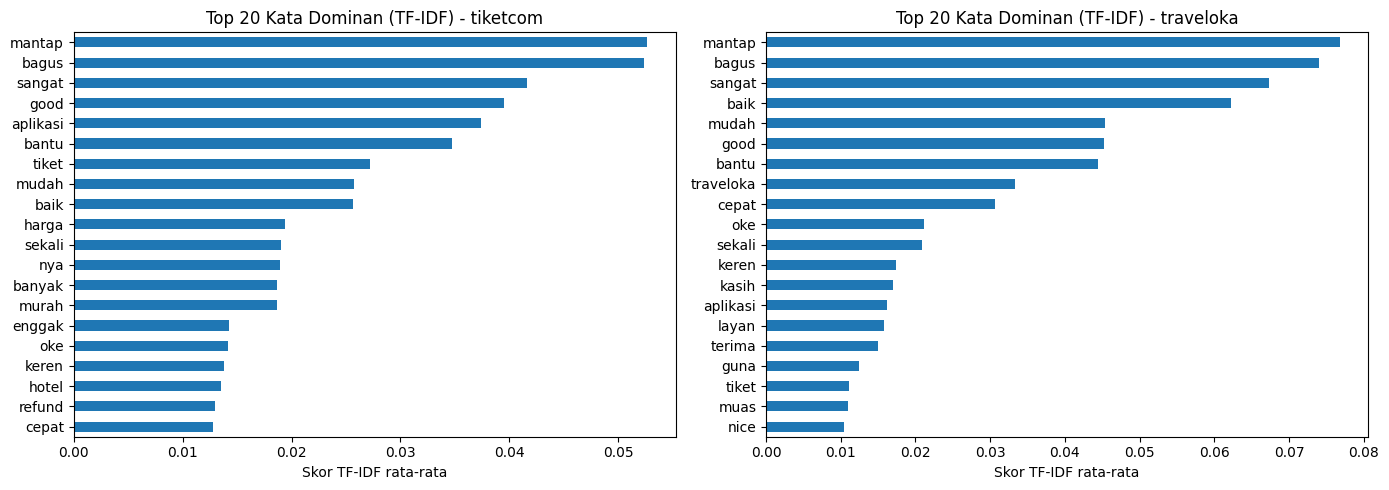

In [20]:
def plot_top_terms_side_by_side(source_left, source_right, k=20, figsize=(14,5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False)

    for ax, source_name in zip(axes, [source_left, source_right]):
        idx = mean_tfidf[source_name].argsort()[::-1][:k]
        top_terms = terms[idx]
        top_scores = mean_tfidf[source_name][idx]

        # biar tampil rapi: sort ascending supaya barh dari bawah ke atas
        s = pd.Series(top_scores, index=top_terms).sort_values()
        s.plot(kind="barh", ax=ax)

        ax.set_title(f"Top {k} Kata Dominan (TF-IDF) - {source_name}")
        ax.set_xlabel("Skor TF-IDF rata-rata")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

plot_top_terms_side_by_side("tiketcom", "traveloka", k=20)


In [21]:
tfidf_bi = TfidfVectorizer(max_features=5000, ngram_range=(2,2))
X_bi = tfidf_bi.fit_transform(df["stemmed_text"].fillna(""))
terms_bi = np.array(tfidf_bi.get_feature_names_out())

mean_bi = {}
for s in df["source"].unique():
    idx = df["source"].eq(s).values
    mean_bi[s] = X_bi[idx].mean(axis=0).A1

for s in mean_bi:
    top_idx = mean_bi[s].argsort()[::-1][:15]
    print("\nTOP 15 bigram -", s)
    print(list(terms_bi[top_idx]))



TOP 15 bigram - tiketcom
['sangat bantu', 'beli tiket', 'sangat bagus', 'terima kasih', 'tiket com', 'banyak promo', 'lebih murah', 'tiket pesawat', 'aplikasi sangat', 'mudah guna', 'pesan tiket', 'banyak diskon', 'bantu sekali', 'sangat baik', 'harga tiket']

TOP 15 bigram - traveloka
['sangat bantu', 'terima kasih', 'sangat baik', 'sangat mudah', 'sangat bagus', 'mudah cepat', 'kasih traveloka', 'bantu sekali', 'the best', 'mudah guna', 'bagus sekali', 'cepat mudah', 'sangat muas', 'aplikasi sangat', 'lebih mudah']


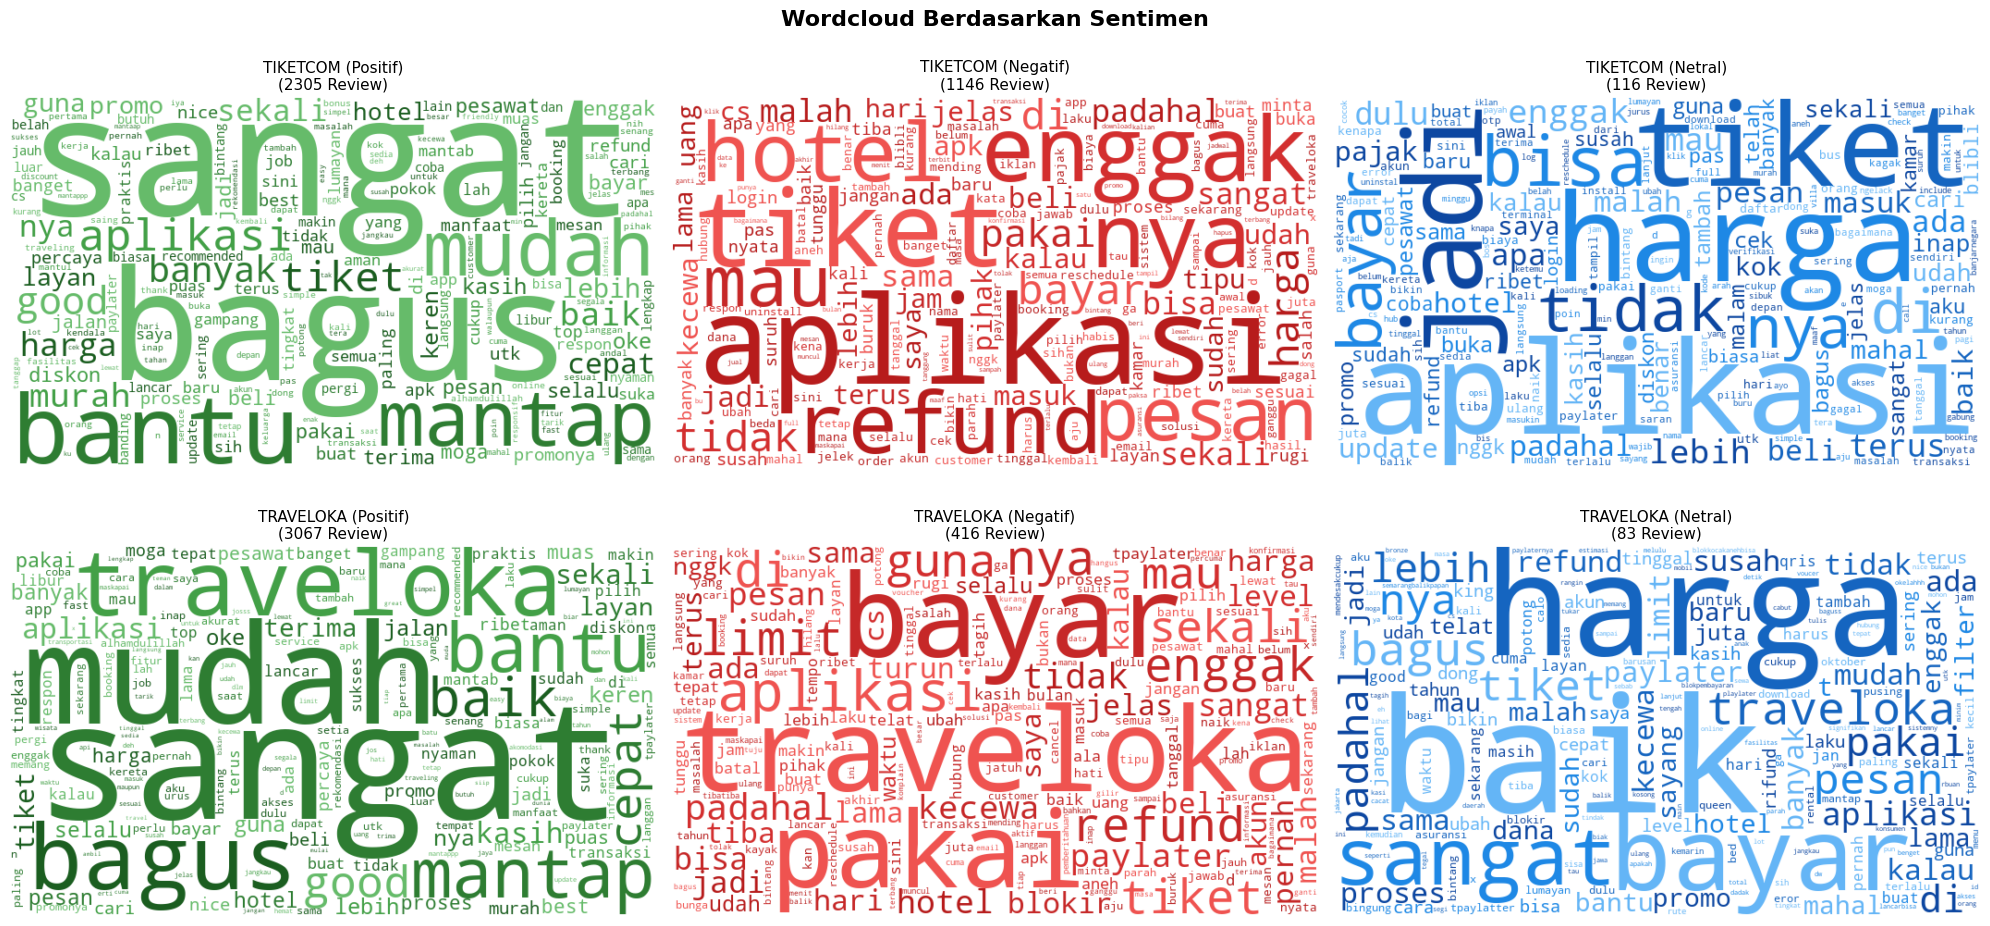

In [48]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random

TEXT_COL = "stemmed_text"
SOURCE_COL = "source"
LABEL_COL = "label"

sources = ["tiketcom", "traveloka"]   # sesuaikan
sentiments = ["positif", "negatif", "netral"]

# Palet warna per sentimen (beberapa gradasi biar tidak 1 warna polos)
PALETTES = {
    "positif": ["#1b5e20", "#2e7d32", "#43a047", "#66bb6a"],
    "negatif": ["#b71c1c", "#c62828", "#d32f2f", "#ef5350"],
    "netral":  ["#0d47a1", "#1565c0", "#1e88e5", "#64b5f6"],
}

def color_func_for(sentiment):
    palette = PALETTES.get(sentiment, ["#333333"])
    def _color(*args, **kwargs):
        return random.choice(palette)
    return _color

def build_text(df, source, sent):
    sub = df[(df[SOURCE_COL] == source) & (df[LABEL_COL] == sent)]
    return " ".join(sub[TEXT_COL].fillna("").astype(str))

def make_wc(text, sent):
    if not str(text).strip():
        text = "kosong"
    return WordCloud(
        width=700,
        height=400,
        background_color="white",
        collocations=False
    ).generate(text).recolor(color_func=color_func_for(sent))

fig, axes = plt.subplots(len(sources), len(sentiments), figsize=(20, 10))

for i, src in enumerate(sources):
    for j, sent in enumerate(sentiments):
        text = build_text(df, src, sent)
        wc = make_wc(text, sent)

        ax = axes[i, j]
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")

        n = df[(df[SOURCE_COL] == src) & (df[LABEL_COL] == sent)].shape[0]
        ax.set_title(f"{src.upper()} ({sent.capitalize()})\n({n} Review)", fontsize=11)

plt.suptitle("Wordcloud Berdasarkan Sentimen", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


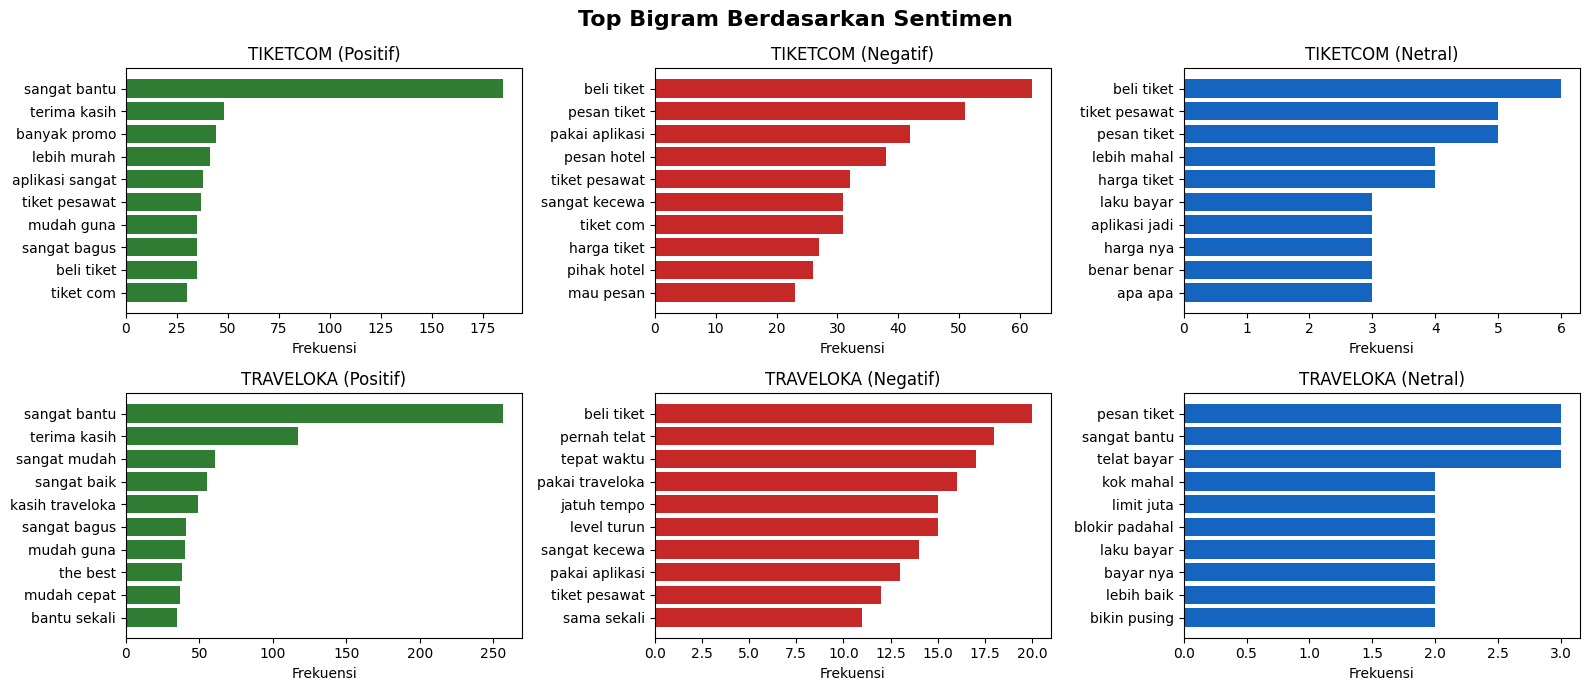

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

TEXT_COL = "stemmed_text"   # atau "no_stop_text"
SOURCE_COL = "source"
LABEL_COL = "label"         # positif/negatif/netral

sources = ["tiketcom", "traveloka"]    # sesuaikan dengan df[SOURCE_COL].unique()
sentiments = ["positif", "negatif", "netral"]

# Warna per sentimen
SENT_COLORS = {
    "positif": "#2e7d32",  # hijau
    "negatif": "#c62828",  # merah
    "netral":  "#1565c0",  # biru
}

def top_bigrams_counts(texts, top_n=10):
    """
    texts: list/Series of strings
    return: Series index=bigram, value=count
    """
    vec = CountVectorizer(ngram_range=(2,2))
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    s = pd.Series(counts, index=terms).sort_values(ascending=False).head(top_n)
    return s

fig, axes = plt.subplots(len(sources), len(sentiments), figsize=(16, 7))
fig.suptitle("Top Bigram Berdasarkan Sentimen", fontsize=16, fontweight="bold")

for i, src in enumerate(sources):
    for j, sent in enumerate(sentiments):
        ax = axes[i, j] if len(sources) > 1 else axes[j]

        sub = df[(df[SOURCE_COL] == src) & (df[LABEL_COL] == sent)]
        texts = sub[TEXT_COL].fillna("").astype(str)

        if texts.str.strip().eq("").all() or len(texts) == 0:
            ax.set_title(f"{src.upper()} ({sent.capitalize()})")
            ax.text(0.5, 0.5, "Tidak ada data", ha="center", va="center")
            ax.axis("off")
            continue

        top = top_bigrams_counts(texts, top_n=10)

        # Barh biar rapi (paling sering di atas)
        top = top.sort_values()  # ascending supaya barh dari bawah ke atas
        ax.barh(top.index, top.values, color=SENT_COLORS[sent])

        ax.set_title(f"{src.upper()} ({sent.capitalize()})")
        ax.set_xlabel("Frekuensi")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()


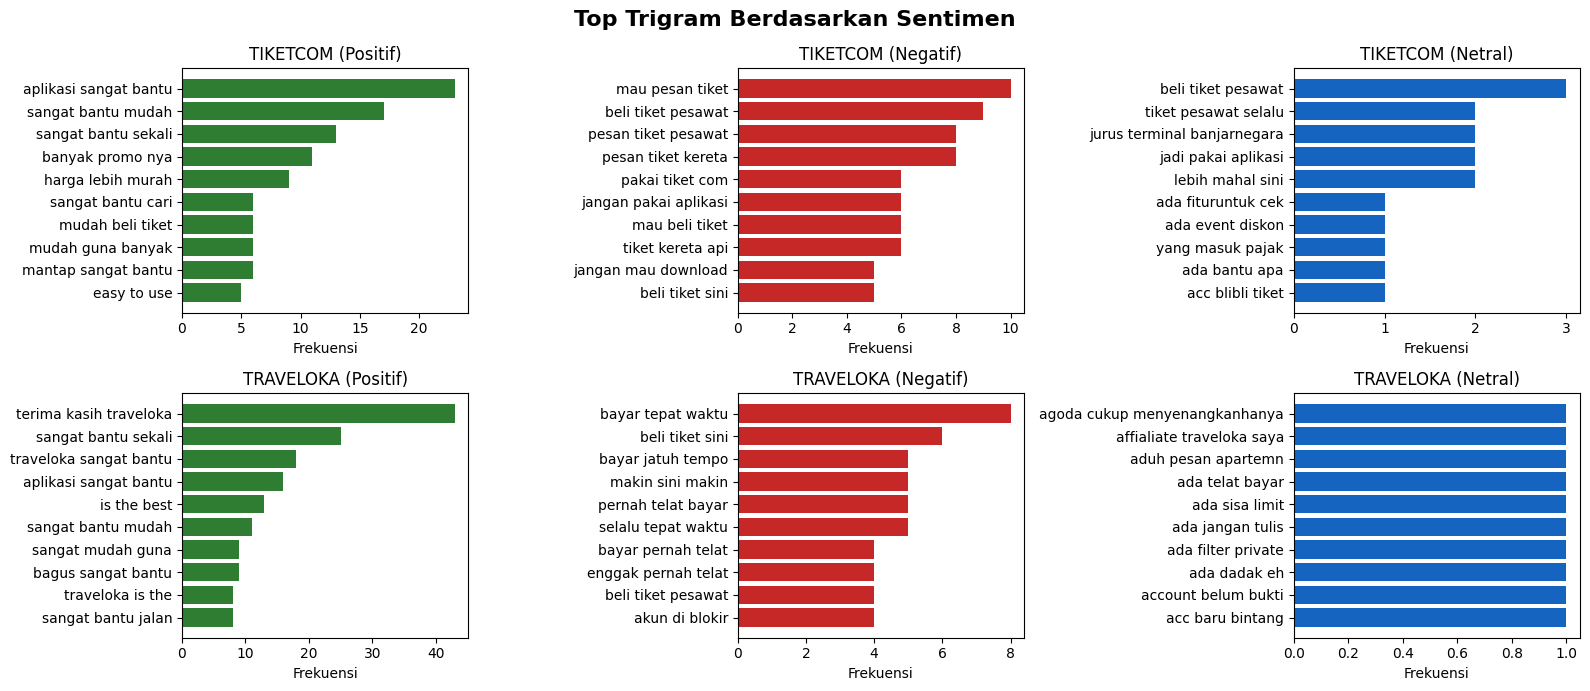

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

TEXT_COL = "stemmed_text"   # atau "no_stop_text"
SOURCE_COL = "source"
LABEL_COL = "label"         # positif/negatif/netral

sources = ["tiketcom", "traveloka"]    # sesuaikan
sentiments = ["positif", "negatif", "netral"]

SENT_COLORS = {
    "positif": "#2e7d32",  # hijau
    "negatif": "#c62828",  # merah
    "netral":  "#1565c0",  # biru
}

def top_trigrams_counts(texts, top_n=10):
    vec = CountVectorizer(ngram_range=(3,3))
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    s = pd.Series(counts, index=terms).sort_values(ascending=False).head(top_n)
    return s

fig, axes = plt.subplots(len(sources), len(sentiments), figsize=(16, 7))
fig.suptitle("Top Trigram Berdasarkan Sentimen", fontsize=16, fontweight="bold")

for i, src in enumerate(sources):
    for j, sent in enumerate(sentiments):
        ax = axes[i, j]

        sub = df[(df[SOURCE_COL] == src) & (df[LABEL_COL] == sent)]
        texts = sub[TEXT_COL].fillna("").astype(str)

        # kalau tidak ada teks
        if len(texts) == 0 or texts.str.strip().eq("").all():
            ax.set_title(f"{src.upper()} ({sent.capitalize()})")
            ax.text(0.5, 0.5, "Tidak ada data", ha="center", va="center")
            ax.axis("off")
            continue

        top = top_trigrams_counts(texts, top_n=10).sort_values()  # barh rapi
        ax.barh(top.index, top.values, color=SENT_COLORS[sent])

        ax.set_title(f"{src.upper()} ({sent.capitalize()})")
        ax.set_xlabel("Frekuensi")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [51]:
df.head()

,reviewId,content,score,at,source,cleaned_content,normalized_text,no_stop_text,tokenized_text,stemmed_tokens,stemmed_text,label,len_words,label_lexicon,label_rating,label_hybrid
0,d84a4955-4bfb-448b-a260-b36935a58c9b,kalo ada pembatalan hub langsung WA dong,1,2026-01-13 12:12:06,tiketcom,kalo ada pembatalan hub langsung wa dong,kalau ada pembatalan hub langsung wa dong,kalau pembatalan hub langsung wa dong,"['kalau', 'pembatalan', 'hub', 'langsung', 'wa...","['kalau', 'batal', 'hub', 'langsung', 'wa', 'd...",kalau batal hub langsung wa dong,negatif,6,negatif,negatif,negatif
1,0b67f755-1fb1-4300-a769-68e45a0a48cc,ganguan terus susah cari jadwal disni,2,2026-01-13 11:18:17,tiketcom,ganguan terus susah cari jadwal disni,ganguan terus susah cari jadwal disni,ganguan terus susah cari jadwal disni,"['ganguan', 'terus', 'susah', 'cari', 'jadwal'...","['ganguan', 'terus', 'susah', 'cari', 'jadwal'...",ganguan terus susah cari jadwal disni,negatif,6,negatif,negatif,negatif
2,fcef9cb8-5c08-41cf-a8b5-2a2eb1edfba8,banyakin promonya ya,5,2026-01-13 00:01:23,tiketcom,banyakin promonya ya,dibanyaki promonya ya,dibanyaki promonya,"['dibanyaki', 'promonya']","['banyak', 'promonya']",banyak promonya,positif,2,positif,positif,positif
3,d039ee95-c3f2-4e76-ae03-9214f7672cd8,very bad service!!!!!!,1,2026-01-12 21:29:45,tiketcom,very bad service,very bad service,very bad service,"['very', 'bad', 'service']","['very', 'bad', 'service']",very bad service,negatif,3,negatif,negatif,negatif
4,0d830287-f7df-454c-9598-4d6a6071b32a,mantap,5,2026-01-12 13:02:48,tiketcom,mantap,mantap,mantap,['mantap'],['mantap'],mantap,positif,1,positif,positif,positif


In [75]:
df.to_csv('data_ready_for_modeling_analist.csv', index=False)
print("Saved to data_ready_for_modeling_analist.csv")

Saved to data_ready_for_modeling_analist.csv
